<a href="https://colab.research.google.com/github/Sanjaiguru06/ML-Practice-Experiments/blob/main/Experiment_9%20Ensemble%20Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Random Forest Accuracy: 0.9496
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       107
           1       0.95      0.96      0.95       131

    accuracy                           0.95       238
   macro avg       0.95      0.95      0.95       238
weighted avg       0.95      0.95      0.95       238

[[100   7]
 [  5 126]]

AdaBoost Accuracy: 0.8739
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       107
           1       0.87      0.90      0.89       131

    accuracy                           0.87       238
   macro avg       0.87      0.87      0.87       238
weighted avg       0.87      0.87      0.87       238

[[ 90  17]
 [ 13 118]]

Gradient Boosting Accuracy: 0.9160
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       107
           1       0.92      0.93      0.92       131

    accuracy                           0.

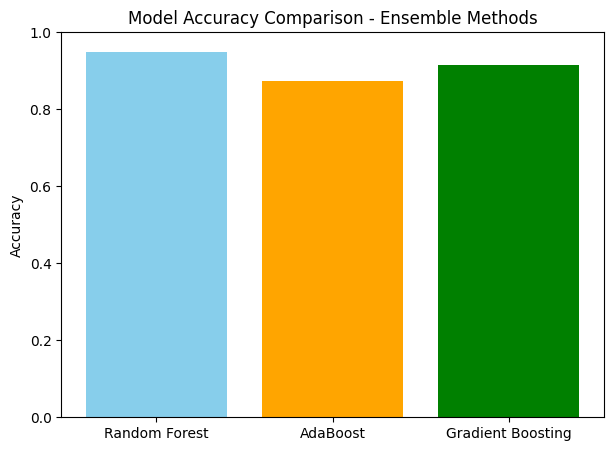

Ensemble modeling completed. Best model: Random Forest
Results saved as 'Ensemble_output.csv'


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

df = pd.read_csv("/content/sample_data/dataset.csv")
X = df.drop(columns=["target"])
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

models = {"Random Forest": rf, "AdaBoost": ada, "Gradient Boosting": gb}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(7,5))
plt.bar(results.keys(), results.values(), color=["skyblue", "orange", "green"])
plt.title("Model Accuracy Comparison - Ensemble Methods")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
df["Best_Model_Prediction"] = best_model.predict(X_scaled)
df.to_csv("Ensemble_output.csv", index=False)
print(f"Ensemble modeling completed. Best model: {best_model_name}")
print("Results saved as 'Ensemble_output.csv'")
